## Feature Engineering and Modeling

In [2]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna


In [3]:
# Load the dataset
df = pd.read_csv('data/train.csv')

In [4]:
# Encoding the target variable
df["Irrigation_Need"] = df["Irrigation_Need"].map({"High": 2,"Medium": 1, "Low": 0})

# Removing the id column as it is not useful for modeling
df.drop("id", axis=1, inplace=True)

In [5]:
# Feature engineering: Creating new features based on existing ones
df['dryness_score'] = (
    -df['Soil_Moisture']
    + df['Temperature_C']
    + df['Wind_Speed_kmh']
    - df['Rainfall_mm']
)

df['low_moisture'] = (df['Soil_Moisture'] < 20.5).astype(int)

df['high_temperature'] = (df['Temperature_C'] > 30).astype(int)

df['high_wind'] = (df['Wind_Speed_kmh'] > 12.5).astype(int)

df['low_rainfall'] = (df['Rainfall_mm'] < 850).astype(int)

df['temp_x_wind'] = df['Temperature_C'] * df['Wind_Speed_kmh']
df['temp_x_sunlight'] = df['Temperature_C'] * df['Sunlight_Hours']
df['wind_x_sunlight'] = df['Wind_Speed_kmh'] * df['Sunlight_Hours']

df['active_growth_stage'] = df['Crop_Growth_Stage'].isin(["Flowering", "Vegetative"]).astype(int)
df['stress_count'] = (
    df['low_moisture'] + df['high_temperature'] + df['high_wind'] + df['low_rainfall'] + df['active_growth_stage']
)

In [6]:
# Splitting the dataset into features and target variable
X = df.drop("Irrigation_Need", axis=1)
y = df["Irrigation_Need"]

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
# Differentiating between numerical and categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [9]:
preprocessor = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    remainder='passthrough'
)

In [13]:
# Using GridSearchCV to find the best hyperparameters for XGBoost because it performed better than Optuna
xgb = XGBClassifier(random_state=42, eval_metric='mlogloss',tree_method='hist')
param_grid = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.03, 0.1],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb)
])
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
best_xgb = grid_search.best_estimator_

Best Hyperparameters: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 500, 'xgb__subsample': 0.8}


In [14]:
# Fitting the best XGBoost model on the training data and evaluating on the test set
best_xgb.fit(X_train, y_train)
y_pred = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99    110927
           1       0.98      0.98      0.98     71683
           2       0.97      0.92      0.94      6390

    accuracy                           0.98    189000
   macro avg       0.98      0.96      0.97    189000
weighted avg       0.98      0.98      0.98    189000



In [20]:

# Feature importance from the trained XGBoost model
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()
importances = best_xgb.named_steps['xgb'].feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

feature_importance.head(20)


,feature,importance
52,remainder__stress_count,0.246615
51,remainder__active_growth_stage,0.125085
45,remainder__high_temperature,0.121833
26,cat__Mulching_Used_Yes,0.093168
46,remainder__high_wind,0.066740
25,cat__Mulching_Used_No,0.059081
47,remainder__low_rainfall,0.055131
44,remainder__low_moisture,0.047831
33,remainder__Soil_Moisture,0.039840
11,cat__Crop_Growth_Stage_Harvest,0.023476


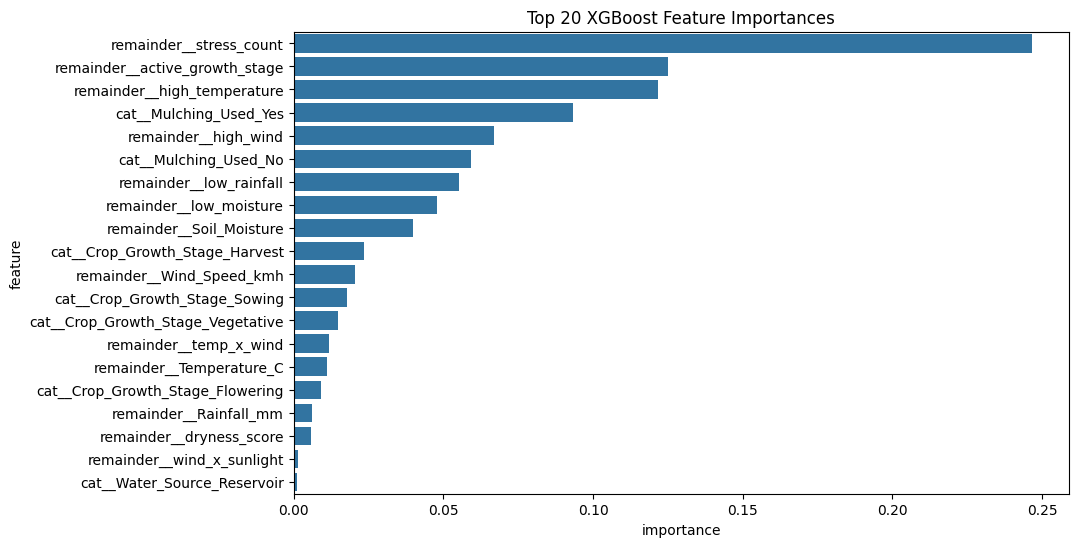

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(20),
    x='importance',
    y='feature'
)
plt.title('Top 20 XGBoost Feature Importances')
plt.show()


In [25]:
# LGBM Model
lgbm = LGBMClassifier(random_state=42, objective='multiclass', verbose=-1, force_row_wise=True)


param_grid_lgbm = {
    "lgbm__n_estimators": [300, 500, 700],
    "lgbm__learning_rate": [0.03, 0.1],
    "lgbm__num_leaves": [31, 63],
    "lgbm__max_depth": [-1, 7],
    "lgbm__subsample": [0.8],
    "lgbm__colsample_bytree": [0.8]
}
pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor.set_output(transform='pandas')),
    ('lgbm', lgbm)
])
grid_search_lgbm = GridSearchCV(estimator=pipeline_lgbm, param_grid=param_grid_lgbm, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
grid_search_lgbm.fit(X_train, y_train)
print("Best Hyperparameters for LGBM:", grid_search_lgbm.best_params_)
best_lgbm = grid_search_lgbm.best_estimator_

Best Hyperparameters for LGBM: {'lgbm__colsample_bytree': 0.8, 'lgbm__learning_rate': 0.03, 'lgbm__max_depth': -1, 'lgbm__n_estimators': 700, 'lgbm__num_leaves': 31, 'lgbm__subsample': 0.8}


In [26]:
# Fitting the best LGBM model on the training data and evaluating on the test set
best_lgbm.fit(X_train, y_train)
y_pred_lgbm = best_lgbm.predict(X_test)
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    110927
           1       0.99      0.98      0.98     71683
           2       0.97      0.92      0.94      6390

    accuracy                           0.99    189000
   macro avg       0.98      0.96      0.97    189000
weighted avg       0.98      0.99      0.98    189000



In [28]:
# Feature Importance from the trained LGBM model
feature_names_lgbm = best_lgbm.named_steps['preprocessor'].get_feature_names_out()
importances_lgbm = best_lgbm.named_steps['lgbm'].feature_importances_
feature_importance_lgbm = pd.DataFrame({
    'feature': feature_names_lgbm,
    'importance': importances_lgbm
}).sort_values('importance', ascending=False)
feature_importance_lgbm.head(20)

,feature,importance
38,remainder__Rainfall_mm,5939
33,remainder__Soil_Moisture,5346
36,remainder__Temperature_C,4568
40,remainder__Wind_Speed_kmh,4141
42,remainder__Previous_Irrigation_mm,4088
37,remainder__Humidity,3913
43,remainder__dryness_score,3291
41,remainder__Field_Area_hectare,2895
32,remainder__Soil_pH,2761
48,remainder__temp_x_wind,2718


In [29]:
# Model Comparison Table
models = ['XGBoost', 'LightGBM']
balanced_accuracies = [
    classification_report(y_test, y_pred, output_dict=True)['weighted avg']['recall'],
    classification_report(y_test, y_pred_lgbm, output_dict=True)['weighted avg']['recall']
]
comparison_df = pd.DataFrame({
    'Model': models,
    'Balanced Accuracy': balanced_accuracies
})
print(comparison_df)

      Model  Balanced Accuracy
0   XGBoost           0.984794
1  LightGBM           0.985032


In [30]:
# Function to convert transformed feature names back to original feature names
def clean_feature_name(feature):
    if feature.startswith("remainder__"):
        return feature.replace("remainder__", "")
    
    if feature.startswith("cat__"):
        feature = feature.replace("cat__", "")
        for col in categorical_features:
            if feature.startswith(col + "_"):
                return col
    
    return feature


In [31]:
# Clean XGBoost importances
xgb_ranked = feature_importance.copy()
xgb_ranked["original_feature"] = xgb_ranked["feature"].apply(clean_feature_name)

xgb_grouped = (
    xgb_ranked
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .rename(columns={"importance": "xgb_importance"})
)

xgb_grouped["xgb_rank"] = xgb_grouped["xgb_importance"].rank(
    ascending=False,
    method="min"
)
# Clean LightGBM importances
lgbm_ranked = feature_importance_lgbm.copy()
lgbm_ranked["original_feature"] = lgbm_ranked["feature"].apply(clean_feature_name)

lgbm_grouped = (
    lgbm_ranked
    .groupby("original_feature", as_index=False)["importance"]
    .sum()
    .rename(columns={"importance": "lgbm_importance"})
)

lgbm_grouped["lgbm_rank"] = lgbm_grouped["lgbm_importance"].rank(
    ascending=False,
    method="min"
)


In [32]:
# Average the ranks from both models
rank_comparison = xgb_grouped.merge(
    lgbm_grouped,
    on="original_feature",
    how="outer"
)

rank_comparison["average_rank"] = rank_comparison[["xgb_rank", "lgbm_rank"]].mean(axis=1)

rank_comparison = rank_comparison.sort_values("average_rank")

rank_comparison.head(20)


,original_feature,xgb_importance,xgb_rank,lgbm_importance,lgbm_rank,average_rank
12,Soil_Moisture,0.039840,9.0,5346,2.0,5.5
9,Rainfall_mm,0.005976,13.0,5939,1.0,7.0
18,Wind_Speed_kmh,0.020609,10.0,4141,4.0,7.0
16,Temperature_C,0.011151,12.0,4568,3.0,7.5
6,Mulching_Used,0.152249,2.0,2329,14.0,8.0
25,stress_count,0.246615,1.0,1561,18.0,9.5
19,active_growth_stage,0.125085,3.0,1565,17.0,10.0
27,temp_x_wind,0.011636,11.0,2718,10.0,10.5
20,dryness_score,0.005678,14.0,3291,7.0,10.5
0,Crop_Growth_Stage,0.065173,6.0,1003,20.0,13.0


In [33]:
top_n = 15

selected_features_ranked = (
    rank_comparison
    .head(top_n)["original_feature"]
    .tolist()
)

selected_features_ranked


['Soil_Moisture',
 'Rainfall_mm',
 'Wind_Speed_kmh',
 'Temperature_C',
 'Mulching_Used',
 'stress_count',
 'active_growth_stage',
 'temp_x_wind',
 'dryness_score',
 'Crop_Growth_Stage',
 'Previous_Irrigation_mm',
 'high_temperature',
 'Humidity',
 'Crop_Type',
 'high_wind']

In [34]:
X_selected = df[selected_features_ranked]
y = df["Irrigation_Need"]

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

numerical_features_sel = X_selected.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_sel = X_selected.select_dtypes(include=["object"]).columns.tolist()

preprocessor_sel = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features_sel),
    ],
    remainder="passthrough"
)


In [35]:
# XGBoost with ranked selected features
xgb_selected = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist",
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=500,
    subsample=0.8
)

xgb_selected_pipeline = Pipeline([
    ("preprocessor", preprocessor_sel),
    ("xgb", xgb_selected)
])

xgb_selected_pipeline.fit(X_train_sel, y_train_sel)

y_pred_xgb_selected = xgb_selected_pipeline.predict(X_test_sel)

print("XGBoost Selected Features")
print(classification_report(y_test_sel, y_pred_xgb_selected))


XGBoost Selected Features
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    110975
           1       0.98      0.98      0.98     71722
           2       0.97      0.91      0.94      6303

    accuracy                           0.98    189000
   macro avg       0.98      0.96      0.97    189000
weighted avg       0.98      0.98      0.98    189000



In [36]:
# LightGBM with ranked selected features
lgbm_selected = LGBMClassifier(
    random_state=42,
    objective="multiclass",
    verbose=-1,
    force_row_wise=True
)

lgbm_selected_pipeline = Pipeline([
    ("preprocessor", preprocessor_sel),
    ("lgbm", lgbm_selected)
])

lgbm_selected_pipeline.fit(X_train_sel, y_train_sel)

y_pred_lgbm_selected = lgbm_selected_pipeline.predict(X_test_sel)

print("LightGBM Selected Features")
print(classification_report(y_test_sel, y_pred_lgbm_selected))


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Selected Features
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    110975
           1       0.98      0.98      0.98     71722
           2       0.96      0.91      0.93      6303

    accuracy                           0.98    189000
   macro avg       0.98      0.96      0.97    189000
weighted avg       0.98      0.98      0.98    189000



In [37]:
xgb_selected_probs = xgb_selected_pipeline.predict_proba(X_test_sel)
lgbm_selected_probs = lgbm_selected_pipeline.predict_proba(X_test_sel)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [39]:
# Comparing XGBoost full features XGBoost selected features LightGBM full features LightGBM selected features
comparison_df = pd.DataFrame({
    "Model": [
        "XGBoost Full Features",
        "XGBoost Selected Features",
        "LightGBM Full Features",
        "LightGBM Selected Features"
    ],
    "Balanced Accuracy": [
        classification_report(y_test, y_pred, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test_sel, y_pred_xgb_selected, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test, y_pred_lgbm, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test_sel, y_pred_lgbm_selected, output_dict=True)["weighted avg"]["recall"]
    ]
})
print(comparison_df)

                        Model  Balanced Accuracy
0       XGBoost Full Features           0.984794
1   XGBoost Selected Features           0.984963
2      LightGBM Full Features           0.985032
3  LightGBM Selected Features           0.984714


In [ ]:
# Probability Averaging Ensemble with Selected Features
ensemble_probs = (xgb_selected_probs + lgbm_selected_probs) / 2
ensemble_preds = ensemble_probs.argmax(axis=1)
print("Ensemble of Selected Features")
print(classification_report(y_test_sel, ensemble_preds))

Ensemble of Selected Features
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    110975
           1       0.98      0.98      0.98     71722
           2       0.97      0.91      0.94      6303

    accuracy                           0.99    189000
   macro avg       0.98      0.96      0.97    189000
weighted avg       0.99      0.99      0.99    189000



In [41]:
# Probability Averaging Ensemble with Full Features
ensemble_probs_full = (best_xgb.predict_proba(X_test) + best_lgbm.predict_proba(X_test)) / 2
ensemble_preds_full = ensemble_probs_full.argmax(axis=1)
print("Ensemble of Full Features")
print(classification_report(y_test, ensemble_preds_full))

Ensemble of Full Features
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    110927
           1       0.99      0.98      0.98     71683
           2       0.97      0.92      0.94      6390

    accuracy                           0.99    189000
   macro avg       0.98      0.96      0.97    189000
weighted avg       0.99      0.99      0.99    189000



In [42]:
# Comparing Stacked Ensemble and Original Models
final_comparison_df = pd.DataFrame({
    "Model": [
        "XGBoost Full Features",
        "XGBoost Selected Features",
        "LightGBM Full Features",
        "LightGBM Selected Features",
        "Ensemble Selected Features",
        "Ensemble Full Features"
    ],
    "Balanced Accuracy": [
        classification_report(y_test, y_pred, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test_sel, y_pred_xgb_selected, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test, y_pred_lgbm, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test_sel, y_pred_lgbm_selected, output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test_sel, ensemble_preds,   output_dict=True)["weighted avg"]["recall"],
        classification_report(y_test, ensemble_preds_full, output_dict=True)["weighted avg"]["recall"]
    ]
})
print(final_comparison_df)

                        Model  Balanced Accuracy
0       XGBoost Full Features           0.984794
1   XGBoost Selected Features           0.984963
2      LightGBM Full Features           0.985032
3  LightGBM Selected Features           0.984714
4  Ensemble Selected Features           0.985132
5      Ensemble Full Features           0.985201


The Ensemble Model with the Full Features seems to perform the best, although it's marginal

In [45]:
test = pd.read_csv("data/test.csv")
# Creating the same features in the test set as in the training set
test['dryness_score'] = (
    -test['Soil_Moisture']
    + test['Temperature_C']
    + test['Wind_Speed_kmh']
    - test['Rainfall_mm']
)   
test['low_moisture'] = (test['Soil_Moisture'] < 20.5).astype(int)
test['high_temperature'] = (test['Temperature_C'] > 30).astype(int)
test['high_wind'] = (test['Wind_Speed_kmh'] > 12.5).astype(int)
test['low_rainfall'] = (test['Rainfall_mm'] < 850).astype(int)
test['temp_x_wind'] = test['Temperature_C'] * test['Wind_Speed_kmh']
test['temp_x_sunlight'] = test['Temperature_C'] * test['Sunlight_Hours']
test['wind_x_sunlight'] = test['Wind_Speed_kmh'] * test['Sunlight_Hours']
test['active_growth_stage'] = test['Crop_Growth_Stage'].isin(["Flowering", "Vegetative"]).astype(int)
test['stress_count'] = (
    test['low_moisture'] + test['high_temperature'] + test['high_wind'] + test['low_rainfall'] + test['active_growth_stage']
)

# Creating the submission file with the Ensemble of Full Features predictions since it performed the best on the test set
test_ids = test["id"]
test.drop("id", axis=1, inplace=True)
test_pred_probs = (best_xgb.predict_proba(test) + best_lgbm.predict_proba(test)) / 2
test_pred_classes = test_pred_probs.argmax(axis=1)
submission = pd.DataFrame({
    "id": test_ids,
    "Irrigation_Need": test_pred_classes
})
submission["Irrigation_Need"] = submission["Irrigation_Need"].map({0: "Low", 1: "Medium", 2: "High"})
submission.to_csv("submission_ensemble.csv", index=False)
submission.head()

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
